# Step 1. 유니버스 구성

- 목적: 날짜별 KOSPI200 구성종목 수가 약 200개인지 확인하고, 편입·편출 이벤트의 수와 시점을 확인한다.
- 유니버스 정의: 각 거래일에 **그날 이하 기준일의 가장 최근 스냅샷**에 있는 종목.
- **v2**: 가격은 KRX 정규장 일봉(`krx_daily_candles`)을 쓴다. v1에서 가격이 없어 뺐던 3종목(003410, 010620, 042670)이 모두 들어와 제외 종목이 없다. 거래정지는 KRX의 `halted` 플래그로 판단한다.
- 범위: 2024-01-02 ~ 2026-06-30. 분석 표본은 2024-04-01부터이고, 그 전은 워밍업이다. 검증 구간 스냅샷(2026-07-01 이후)은 읽지 않는다.
- 산출물: `data/cache/universe_train.parquet`, `outputs/figures/02_*.png`

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.db import get_engine, read_sql
from src.universe import EXCLUDED_SYMBOLS, build_universe, load_calendar, load_membership, membership_events
from src import plotting as P

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)
P.setup()

DATA_START, SAMPLE_START, TRAIN_END = "2024-01-02", "2024-04-01", "2026-06-30"
engine = get_engine()
q = lambda sql, **kw: read_sql(sql, engine, params=kw or None)

## 1. 데이터 읽기

In [2]:
cal = load_calendar(DATA_START, TRAIN_END, engine)   # 거래일은 기존 일봉과 KRX 일봉이 같다(660일)
mem = load_membership(TRAIN_END, engine)
names = q("SELECT symbol, name, list_date FROM stocks").set_index("symbol")
names["list_date"] = pd.to_datetime(names["list_date"])

# 거래 여부 확인용 KRX 일봉 키(거래량, 거래정지). 학습 구간까지만 읽는다.
cache = ROOT / "data" / "cache" / "krx_keys_2024-01_2026-06.parquet"
if cache.exists():
    keys = pd.read_parquet(cache)
else:
    keys = q("SELECT symbol, trade_date, volume, halted FROM krx_daily_candles WHERE trade_date <= :e", e=TRAIN_END)
    keys["trade_date"] = pd.to_datetime(keys["trade_date"])
    keys["volume"] = keys["volume"].astype(float)
    keys["halted"] = keys["halted"].astype(bool)
    cache.parent.mkdir(parents=True, exist_ok=True)
    keys.to_parquet(cache, index=False)

print(f"거래일 {len(cal)}일 ({cal.min().date()} ~ {cal.max().date()}), 스냅샷 {mem.snapshot_date.nunique()}개, 일봉 키 {len(keys):,}행")

거래일 606일 (2024-01-02 ~ 2026-06-30), 스냅샷 30개, 일봉 키 137,632행


## 2. 날짜별 구성종목 수

In [3]:
uni_all = build_universe(cal, mem, exclude=())   # 제외 전
uni = build_universe(cal, mem)                   # 제외 후 (분석용)

cnt = pd.DataFrame({
    "n_members": uni_all.groupby("trade_date").size(),
    "n_universe": uni.groupby("trade_date").size(),
}).reindex(cal).fillna(0).astype(int)
cnt["in_sample"] = cnt.index >= SAMPLE_START

s = cnt[cnt["in_sample"]]
display(s.groupby(["n_members", "n_universe"]).size().rename("n_days").reset_index()
        .assign(first=lambda d: [s[(s.n_members == a) & (s.n_universe == b)].index.min().date() for a, b in zip(d.n_members, d.n_universe)],
                last=lambda d: [s[(s.n_members == a) & (s.n_universe == b)].index.max().date() for a, b in zip(d.n_members, d.n_universe)]))
print(f"분석 표본(2024-04-01~): {s.index.size}거래일, (날짜, 종목) {s.n_universe.sum():,}쌍, "
      f"제외로 빠진 쌍 {(s.n_members - s.n_universe).sum():,}")

,n_members,n_universe,n_days,first,last
0,200,200,484,2024-04-01,2026-06-30
1,201,201,61,2024-10-02,2024-12-30


분석 표본(2024-04-01~): 545거래일, (날짜, 종목) 109,061쌍, 제외로 빠진 쌍 0


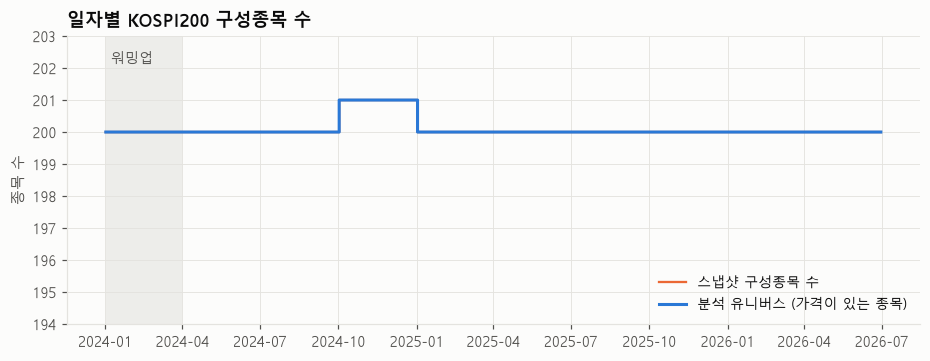

In [4]:
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.step(cnt.index, cnt["n_members"], where="post", color=P.SERIES[1], lw=1.5, label="스냅샷 구성종목 수")
ax.step(cnt.index, cnt["n_universe"], where="post", color=P.SERIES[0], lw=2, label="분석 유니버스 (가격이 있는 종목)")
ax.axvspan(cal.min(), pd.Timestamp(SAMPLE_START), color=P.GRID, alpha=0.6, lw=0)
ax.text(cal.min(), 202.3, " 워밍업", color=P.TEXT_2, fontsize=9, va="center")
ax.set_ylim(194, 203)
ax.set_ylabel("종목 수")
ax.set_title("일자별 KOSPI200 구성종목 수")
ax.legend(loc="lower right", frameon=False, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
P.save(fig, "02_universe_daily_count")
plt.show()

## 3. 편입·편출 이벤트

In [5]:
ev = membership_events(mem)
# stocks 테이블에 없는 폐지·합병 종목의 이름(코드와 시점으로 추정)
DELISTED = {"003410": "쌍용C&E(추정)", "010620": "HD현대미포(추정)", "042670": "HD현대인프라코어(추정)"}
ev["name"] = ev["symbol"].map(names["name"]).fillna(ev["symbol"].map(DELISTED)).fillna("(마스터 없음)")
ev["list_date"] = ev["symbol"].map(names["list_date"]).dt.date
ev["excluded"] = ev["symbol"].isin(EXCLUDED_SYMBOLS)
# 정기변경(6·12월) 결과가 반영되는 스냅샷은 7월 1일, 1월 1일이다
ev["kind"] = np.where(ev["snapshot_date"].dt.month.isin([1, 7]), "정기(추정)", "수시(추정)")

per_snap = ev.pivot_table(index=["snapshot_date", "kind"], columns="event", values="symbol", aggfunc="size", fill_value=0)
display(per_snap.reset_index())
print("합계:", ev["event"].value_counts().to_dict(), "| 정기/수시:", ev.groupby("kind").size().to_dict())

event,snapshot_date,kind,IN,OUT
0,2024-04-01,수시(추정),1,1
1,2024-07-01,정기(추정),6,6
2,2024-10-01,수시(추정),1,0
3,2025-01-01,정기(추정),4,5
4,2025-04-01,수시(추정),1,1
5,2025-07-01,정기(추정),8,8
6,2025-12-01,수시(추정),1,1
7,2026-01-01,정기(추정),8,8


합계: {'IN': 30, 'OUT': 30} | 정기/수시: {'수시(추정)': 7, '정기(추정)': 53}


In [6]:
ev.sort_values(["snapshot_date", "event", "symbol"])[["snapshot_date", "event", "kind", "symbol", "name", "list_date", "excluded"]]

,snapshot_date,event,kind,symbol,name,list_date,excluded
0,2024-04-01,IN,수시(추정),022100,포스코DX,2024-01-02,False
1,2024-04-01,OUT,수시(추정),031430,신세계인터내셔날,2011-07-14,False
2,2024-07-01,IN,정기(추정),003030,세아제강지주,1969-05-13,False
3,2024-07-01,IN,정기(추정),005070,코스모신소재,1987-09-28,False
4,2024-07-01,IN,정기(추정),042700,한미반도체,2005-07-22,False
5,2024-07-01,IN,정기(추정),066970,엘앤에프,2024-01-29,False
6,2024-07-01,IN,정기(추정),454910,두산로보틱스,2023-10-05,False
7,2024-07-01,IN,정기(추정),457190,이수스페셜티케미컬,2023-05-31,False
8,2024-07-01,OUT,정기(추정),000990,DB하이텍,1975-12-12,False
9,2024-07-01,OUT,정기(추정),003410,쌍용C&E(추정),NaT,False


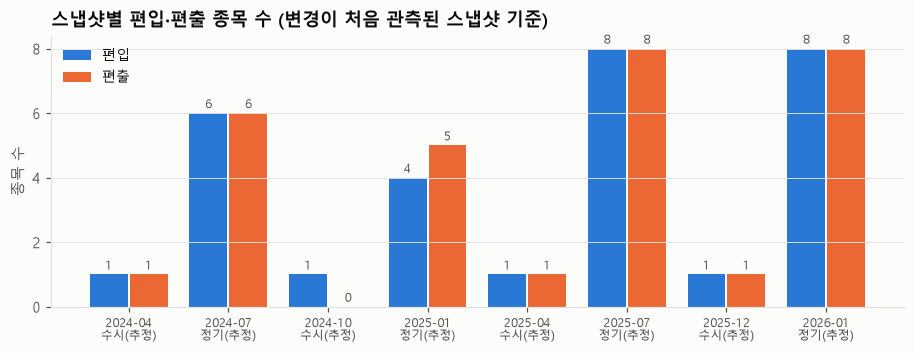

In [7]:
fig, ax = plt.subplots(figsize=(10, 3.2))
x = per_snap.reset_index()
lbl = x["snapshot_date"].dt.strftime("%Y-%m")
pos = np.arange(len(x))
ax.bar(pos - 0.2, x.get("IN", 0), width=0.38, color=P.SERIES[0], label="편입")
ax.bar(pos + 0.2, x.get("OUT", 0), width=0.38, color=P.SERIES[1], label="편출")
for i, (a, b) in enumerate(zip(x.get("IN", 0), x.get("OUT", 0))):
    ax.text(i - 0.2, a + 0.15, a, ha="center", fontsize=8, color=P.TEXT_2)
    ax.text(i + 0.2, b + 0.15, b, ha="center", fontsize=8, color=P.TEXT_2)
ax.set_xticks(pos, [f"{l}\n{k}" for l, k in zip(lbl, x["kind"])], fontsize=8)
ax.set_ylabel("종목 수")
ax.set_title("스냅샷별 편입·편출 종목 수 (변경이 처음 관측된 스냅샷 기준)")
ax.legend(frameon=False, fontsize=9)
ax.grid(axis="x", visible=False)
P.save(fig, "02_universe_events")
plt.show()

## 4. 스냅샷 반영 시차

스냅샷은 매월 1일 기준이라, 실제 효력일과 유니버스 반영일 사이에 시차가 생긴다.

- **정기변경**: KRX 규칙상 6월·12월 선물·옵션 최종거래일(둘째 목요일)의 **다음 거래일**부터 효력이 있다. 이것은 데이터에서 확인한 사실이 아니라 **공개 규칙에 근거한 추정**이다.
- **수시변경**(상장폐지, 합병, 신규 대형 상장 특례 편입 등): 효력일을 이 DB에서 알 수 없다. 최대 약 1개월 늦게 반영될 수 있다.

아래는 정기변경 효력일(추정)부터 스냅샷 반영 직전까지, 유니버스가 실제와 다를 수 있는 (날짜, 종목) 쌍의 수다.

In [8]:
def second_thursday(y, m):
    d = pd.Timestamp(y, m, 1)
    first_thu = d + pd.Timedelta(days=(3 - d.weekday()) % 7)
    return first_thu + pd.Timedelta(days=7)

rows, GAP_DAYS = [], []
for (y, m) in [(2024, 6), (2024, 12), (2025, 6), (2025, 12)]:
    expiry = second_thursday(y, m)
    eff = cal[cal > expiry].min()                                  # 효력일(추정)
    snap = pd.Timestamp(y + (m == 12), 1 if m == 12 else 7, 1)     # 반영 스냅샷
    gap_days = cal[(cal >= eff) & (cal < snap)]
    GAP_DAYS.extend(gap_days)
    e = ev[(ev.snapshot_date == snap) & ~ev.excluded]
    rows.append({"정기변경": f"{y}-{m:02d}", "최종거래일": expiry.date(), "효력일(추정)": eff.date(),
                 "반영 스냅샷": snap.date(), "시차 거래일": len(gap_days),
                 "편입": (e.event == "IN").sum(), "편출": (e.event == "OUT").sum(),
                 "영향 (날짜, 종목) 쌍": len(gap_days) * len(e)})
lag = pd.DataFrame(rows)
display(lag)
n_pairs = cnt.loc[cnt.in_sample, "n_universe"].sum()
print(f"정기변경 시차로 틀릴 수 있는 쌍: {lag['영향 (날짜, 종목) 쌍'].sum():,} / 분석 표본 {n_pairs:,} "
      f"({lag['영향 (날짜, 종목) 쌍'].sum() / n_pairs:.2%})")

,정기변경,최종거래일,효력일(추정),반영 스냅샷,시차 거래일,편입,편출,"영향 (날짜, 종목) 쌍"
0,2024-06,2024-06-13,2024-06-14,2024-07-01,11,6,6,132
1,2024-12,2024-12-12,2024-12-13,2025-01-01,11,4,5,99
2,2025-06,2025-06-12,2025-06-13,2025-07-01,12,8,8,192
3,2025-12,2025-12-11,2025-12-12,2026-01-01,12,8,8,192


정기변경 시차로 틀릴 수 있는 쌍: 615 / 분석 표본 109,061 (0.56%)


## 5. 구성종목 기간의 가격 존재 여부

In [9]:
kv = keys.set_index(["trade_date", "symbol"])["volume"]
kh = keys.set_index(["trade_date", "symbol"])["halted"]
u = uni.set_index(["trade_date", "symbol"])
u["has_candle"] = u.index.isin(kv.index)
u["volume"] = kv.reindex(u.index).values
u["halted"] = kh.reindex(u.index).fillna(False).astype(bool).values
u = u.reset_index()
u["in_sample"] = u["trade_date"] >= SAMPLE_START

s = u[u.in_sample]
print(f"분석 표본 {len(s):,}쌍 중 일봉 없음 {(~s.has_candle).sum():,}, 거래정지 {s.halted.sum():,}")
display(s[s.halted | ~s.has_candle].assign(name=lambda d: d.symbol.map(names["name"]))
        .groupby(["symbol", "name"]).agg(n_days=("trade_date", "size"), first=("trade_date", "min"), last=("trade_date", "max"))
        .reset_index())

분석 표본 109,061쌍 중 일봉 없음 0, 거래정지 115


,symbol,name,n_days,first,last
0,001570,금양,8,2024-10-29,2025-03-31
1,003620,KG모빌리티,18,2025-04-10,2025-05-08
2,004800,효성,22,2024-06-27,2024-07-26
3,007070,GS리테일,17,2024-11-28,2024-12-20
4,010120,LS ELECTRIC,3,2026-04-08,2026-04-10
5,012450,한화에어로스페이스,18,2024-08-29,2024-09-26
6,207940,삼성바이오로직스,17,2025-10-30,2025-11-21
7,377300,카카오페이,2,2025-06-24,2025-06-26


## 6. 편출 후 타깃 계산 가능 여부

편출 직전 표본의 MDD_5에는 편출 후 5거래일 가격이 필요하다. 편출 종목마다 마지막 구성종목 거래일 다음 5거래일에 일봉이 있는지 확인한다(모두 학습 구간 안).

In [10]:
out = ev[ev.event == "OUT"].copy()
pos_of = {d: i for i, d in enumerate(cal)}
res = []
for _, r in out.iterrows():
    last_member = cal[cal < r.snapshot_date].max()
    nxt = cal[pos_of[last_member] + 1: pos_of[last_member] + 6]
    have = kv.reindex(pd.MultiIndex.from_product([nxt, [r.symbol]])).notna().sum()
    res.append({"symbol": r.symbol, "name": r["name"], "snapshot": r.snapshot_date.date(),
                "last_member_day": last_member.date(), "next5_with_candle": int(have), "excluded": r.excluded})
out_chk = pd.DataFrame(res)
display(out_chk[out_chk.next5_with_candle < 5])
print(f"편출 {len(out_chk)}건 중 다음 5거래일 가격이 모두 있는 경우 {(out_chk.next5_with_candle == 5).sum()}건, "
      f"제외 3종목 {out_chk.excluded.sum()}건")

,symbol,name,snapshot,last_member_day,next5_with_candle,excluded


편출 30건 중 다음 5거래일 가격이 모두 있는 경우 30건, 제외 3종목 0건


## 7. 편입 시점의 과거 가격 길이

신규 상장·이전상장 직후 편입된 종목은 파생변수(최대 60거래일)를 계산할 과거 가격이 부족하다. 각 표본 쌍마다 그날까지(당일 포함) 쌓인 일봉 수를 센다.

In [11]:
keys_sorted = keys.sort_values(["symbol", "trade_date"])
keys_sorted["hist_days"] = keys_sorted.groupby("symbol").cumcount() + 1   # 당일 포함 누적 일봉 수
u = u.merge(keys_sorted[["symbol", "trade_date", "hist_days"]], on=["symbol", "trade_date"], how="left")
s = u[u.in_sample]
short = s[s.hist_days < 61]
print(f"분석 표본 중 누적 일봉 61개 미만(60일 수익률 계산 불가): {len(short):,}쌍, {short.symbol.nunique()}종목")
first_candle = keys.groupby("symbol")["trade_date"].min()
display(short.groupby("symbol").agg(n_pairs=("trade_date", "size"), first_pair=("trade_date", "min"),
                                    min_hist=("hist_days", "min")).reset_index()
        .assign(name=lambda d: d.symbol.map(names["name"]),
                list_date=lambda d: d.symbol.map(names["list_date"]).dt.date,
                first_candle=lambda d: d.symbol.map(first_candle).dt.date))

분석 표본 중 누적 일봉 61개 미만(60일 수익률 계산 불가): 113쌍, 2종목


,symbol,n_pairs,first_pair,min_hist,name,list_date,first_candle
0,0126Z0,55,2025-12-01,6,삼성에피스홀딩스,2025-11-24,2025-11-24
1,489790,58,2024-10-02,3,한화비전,2024-09-27,2024-09-27


## 8. 플래그와 캐시 저장

In [12]:
last5 = cal[cal <= TRAIN_END][-5:]
u["embargo"] = u["trade_date"].isin(last5)            # 타깃 구간이 검증 구간과 겹침
u["enough_hist_60"] = u["hist_days"] >= 61             # 60일 수익률 계산 가능
u["rebal_gap_day"] = u["trade_date"].isin(GAP_DAYS)   # 정기변경 효력일(추정)~스냅샷 반영 전: 구성종목이 실제와 다를 수 있음
u = u[["trade_date", "symbol", "snapshot_date", "in_sample", "embargo", "has_candle", "halted",
       "hist_days", "enough_hist_60", "rebal_gap_day"]]
u.to_parquet(ROOT / "data" / "cache" / "universe_train.parquet", index=False)

s = u[u.in_sample]
summary = pd.Series({
    "분석 표본 거래일": s.trade_date.nunique(),
    "분석 표본 (날짜, 종목) 쌍": len(s),
    "종목 수(한 번이라도)": s.symbol.nunique(),
    "엠바고 쌍 (학습 마지막 5거래일)": int(s.embargo.sum()),
    "일봉 없음": int((~s.has_candle).sum()),
    "거래정지": int(s.halted.sum()),
    "과거 일봉 61개 미만": int((~s.enough_hist_60).sum()),
    "정기변경 시차 구간 일자의 쌍 (전체, 실제로 틀린 쌍은 4절)": int(s.rebal_gap_day.sum()),
})
print("엠바고 일자:", [d.date() for d in last5])
summary.to_frame("값")

엠바고 일자: [datetime.date(2026, 6, 24), datetime.date(2026, 6, 25), datetime.date(2026, 6, 26), datetime.date(2026, 6, 29), datetime.date(2026, 6, 30)]


,값
분석 표본 거래일,545
"분석 표본 (날짜, 종목) 쌍",109061
종목 수(한 번이라도),228
엠바고 쌍 (학습 마지막 5거래일),1000
일봉 없음,0
거래정지,115
과거 일봉 61개 미만,113
"정기변경 시차 구간 일자의 쌍 (전체, 실제로 틀린 쌍은 4절)",9211


## 9. 요약 (v2, KRX 일봉 기준)

| 항목 | 결과 |
|---|---|
| 분석 표본 | 2024-04-01 ~ 2026-06-30, 545거래일, (날짜, 종목) **109,061쌍**, 228종목. v1보다 889쌍 늘었다(폐지·합병 3종목 복구) |
| 구성종목 수 | 매일 200개. 2024-10-02 ~ 12-30(61일)만 201개(한화비전 신규 상장 편입 후 다음 정기변경까지 유지된 것으로 추정) |
| 편입·편출 이벤트 | 스냅샷 8개 시점에서 편입 30건, 편출 30건. 정기변경(7월·1월 스냅샷) 4회에 편입 26, 편출 27. 수시변경 4회에 편입 4, 편출 3 |
| 스냅샷 반영 시차 | 정기변경은 효력일(추정)보다 11 ~ 12거래일 늦게 반영된다. 틀릴 수 있는 쌍은 615개(0.56%)다. 수시변경의 시차는 알 수 없다 |
| 편출 후 가격 | **편출 30건 모두** 편출 뒤 5거래일 가격이 있다. v1의 생존 편향 문제가 해결됐다 |
| 거래정지 | t일에 정지 중인 표본은 115쌍, 8종목이다(KRX `halted`). 금양(001570)은 2025-03-24부터 계속 정지 상태지만, 구성종목 기간(~2025-03-31)과 겹치는 것은 8쌍뿐이다 |
| 과거 가격 부족 | 113쌍, 2종목(한화비전, 삼성에피스홀딩스). 상장 직후 편입돼 60일 수익률을 계산할 수 없다. 코스닥에서 옮겨 온 066970, 034230은 이전 뒤 60거래일이 지나서 편입됐으므로 해당하지 않는다 |
| 엠바고 | 2026-06-24 ~ 06-30, 1,000쌍 |

`data/cache/universe_train.parquet`의 플래그: `in_sample`, `embargo`, `has_candle`, `halted`, `hist_days`, `enough_hist_60`, `rebal_gap_day`